### **Regime-Aware ETH Trading Intelligence — Research Notebook**

This notebook serves as an **analysis and validation layer** for the project.

Coverage:
- Data preparation and integrity checks
- Exploratory Data Analysis (EDA)
- Feature behavior across market regimes
- Model selection and hyperparameter tuning (offline)

All production logic (feature engineering, regimes, training pipelines, inference)
lives in standalone Python scripts.
This notebook **does not define trading logic or signals**.

In [135]:
# =========================
# Imports & Configuration
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sys
sys.path.append(".")


plt.style.use("default")

In [136]:
# =========================
# Data Loading (Pipeline)
# =========================

from loader.pipeline import load_and_prepare_data

df = load_and_prepare_data()
df.head()


📂 Loading cached data...
✅ whale: 3012 rows
✅ market: 3012 rows
✅ btc: 4642 rows
✅ eth: 3812 rows
✅ funding: 3012 rows
🔧 Engineering features...
✅ Merged funding data: 3012 rows
✅ Created vol_ratio feature
✅ Features engineered: 55 columns, 3012 rows
📈 Defining all regimes (R0-R5)...
   R5 days detected: 786 (26.1%)

📊 Regime Distribution:
  🟢 R1:  338 ( 11.2%) | ⚪ R2:  345 ( 11.5%)
  🔴 R3:  327 ( 10.9%) | ⚪ R4:  223 (  7.4%)
  🔴 R5:  786 ( 26.1%) | ⚪ R0:  993 ( 33.0%)


,block_date,withdrawal_tx_count,std_whale_tx_size_eth,deposit_withdrawal_ratio,non_exchange_volume_eth,mega_whale_ratio,mega_whale_volume_eth,whale_volume_eth,non_exchange_ratio,net_flow_ma7,...,btc_vol30,btc_rsi,eth_btc_ratio,eth_btc_ratio_ma7,eth_btc_corr_30d,vol_ratio,regime_code,btc_regime,vol_regime,regime
0,2017-10-16 00:00:00+00:00,5.0,2310.607296,0.5146,3.382636e+05,0.8971,3.335630e+05,3.718084e+05,0.9098,10749.2728,...,0.0,0.0,0.057946,0.0,0.0,0.0,R0,NaN,LOW,nan_LOW
1,2017-10-17 00:00:00+00:00,15.0,13716.203240,1.5295,1.017314e+06,0.9456,1.055398e+06,1.116134e+06,0.9115,-20684.9471,...,0.0,0.0,0.056326,0.0,0.0,0.0,R0,NaN,LOW,nan_LOW
2,2017-10-18 00:00:00+00:00,5.0,3957.459236,1.6254,9.463566e+05,1.0000,9.872356e+05,9.872356e+05,0.9586,-15211.3463,...,0.0,0.0,0.056225,0.0,0.0,0.0,R0,NaN,LOW,nan_LOW
3,2017-10-19 00:00:00+00:00,6.0,2819.239036,0.1403,4.850454e+05,0.7803,4.221430e+05,5.409664e+05,0.8966,3912.9137,...,0.0,0.0,0.054153,0.0,0.0,0.0,R0,NaN,LOW,nan_LOW
4,2017-10-20 00:00:00+00:00,10.0,3236.014159,0.9605,6.113884e+05,0.8360,5.448516e+05,6.517544e+05,0.9381,3137.9499,...,0.0,0.0,0.050793,0.0,0.0,0.0,R0,NaN,LOW,nan_LOW


In [137]:
df.columns

Index(['block_date', 'withdrawal_tx_count', 'std_whale_tx_size_eth',
       'deposit_withdrawal_ratio', 'non_exchange_volume_eth',
       'mega_whale_ratio', 'mega_whale_volume_eth', 'whale_volume_eth',
       'non_exchange_ratio', 'net_flow_ma7', 'whale_exchange_withdrawals_eth',
       'exchange_volume_ratio', 'whale_exchange_deposits_eth',
       'non_exchange_tx_count', 'whale_tx_count', 'mega_whale_tx_count',
       'deposit_tx_count', 'whale_net_exchange_flow_eth', 'btc_price',
       'eth_price', 'eth_burned_zscore_90d', 'median_gas_delta_1d',
       'tx_per_active_zscore_90d', 'median_gas_delta_7d',
       'whale_exchange_asymmetry', 'eth_burned_delta_1d',
       'net_exchange_flow_ratio', 'whale_tx_zscore_90d',
       'whale_volume_ratio_delta_1d', 'whale_exchange_flow_ratio',
       'block_fullness_delta_1d', 'smart_contract_ratio_delta_1d',
       'tx_per_active_delta_1d', 'whale_volume_ratio', 'exchange_flow_share',
       'whale_volume_ratio_delta_3d', 'eth_funding_rate_8h

- Data Integrity Checks

In [138]:


print("Dataset Info:")
df.info()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3012 entries, 0 to 3011
Data columns (total 59 columns):
 #   Column                          Non-Null Count  Dtype              
---  ------                          --------------  -----              
 0   block_date                      3012 non-null   datetime64[ns, UTC]
 1   withdrawal_tx_count             3012 non-null   float64            
 2   std_whale_tx_size_eth           3012 non-null   float64            
 3   deposit_withdrawal_ratio        3012 non-null   float64            
 4   non_exchange_volume_eth         3012 non-null   float64            
 5   mega_whale_ratio                3012 non-null   float64            
 6   mega_whale_volume_eth           3012 non-null   float64            
 7   whale_volume_eth                3012 non-null   float64            
 8   non_exchange_ratio              3012 non-null   float64            
 9   net_flow_ma7                    3012 non-null   float64            
 10

In [139]:
print("\nMissing Values (Top 10):")
print(df.isna().sum().sort_values(ascending=False).head(10))



Missing Values (Top 10):
btc_regime                  6
withdrawal_tx_count         0
block_date                  0
deposit_withdrawal_ratio    0
non_exchange_volume_eth     0
mega_whale_ratio            0
mega_whale_volume_eth       0
whale_volume_eth            0
non_exchange_ratio          0
net_flow_ma7                0
dtype: int64


In [140]:
print("\nDistribution Summary:")
print(df.describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]))


Distribution Summary:
       withdrawal_tx_count  std_whale_tx_size_eth  deposit_withdrawal_ratio  \
count          3012.000000            3012.000000               3012.000000   
mean             16.021248            9659.519627                  2.456559   
std              22.545593           10483.167768                  3.118600   
min               0.000000             996.169341                  0.000000   
1%                2.000000            1957.205099                  0.258385   
5%                4.000000            2670.786222                  0.571040   
50%              12.000000            6682.398324                  1.719350   
95%              32.000000           26316.201995                  6.166675   
99%             132.780000           52096.298743                 13.903619   
max             322.000000          167197.516402                 59.401000   

       non_exchange_volume_eth  mega_whale_ratio  mega_whale_volume_eth  \
count             3.012000e+03  

In [141]:
# Missing Value Summary

missing_summary = df.isna().sum()
missing_summary[missing_summary > 0]


btc_regime    6
dtype: int64

In [142]:
df["regime_code"].value_counts(normalize=True).sort_index()


regime_code
R0    0.329681
R1    0.112218
R2    0.114542
R3    0.108566
R4    0.074037
R5    0.260956
Name: proportion, dtype: float64


Regime Distribution (Proportions):
regime_code
R0    0.329681
R5    0.260956
R2    0.114542
R1    0.112218
R3    0.108566
R4    0.074037
Name: proportion, dtype: float64


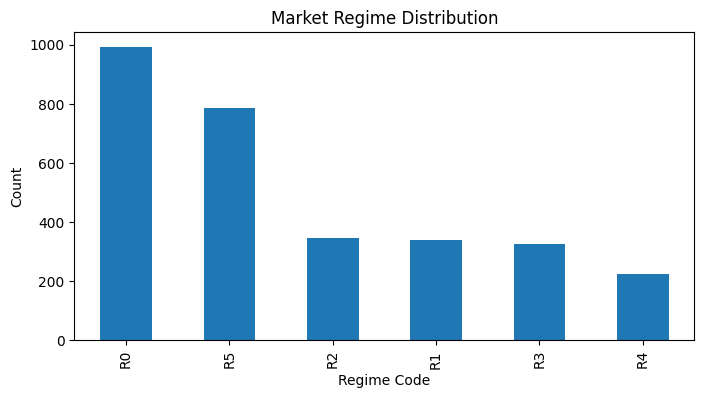

In [143]:
# =========================
# Regime Analysis
# =========================

print("\nRegime Distribution (Proportions):")
print(df["regime_code"].value_counts(normalize=True))

plt.figure(figsize=(8, 4))
df["regime_code"].value_counts().plot(kind="bar")
plt.title("Market Regime Distribution")
plt.xlabel("Regime Code")
plt.ylabel("Count")
plt.show()



In [144]:
# R5 specific analysis
r5_count = (df["regime_code"] == "R5").sum()
print(f"\nR5 regime occurrences: {r5_count} ({r5_count/len(df)*100:.2f}%)")


R5 regime occurrences: 786 (26.10%)


- A small number of missing values appear in derived regime labels due to rolling window requirements. 
- These rows are excluded during model training and backtesting to avoid leakage or artificial smoothing.

In [145]:
#df = df.dropna(subset=["btc_regime"])

- Price Context

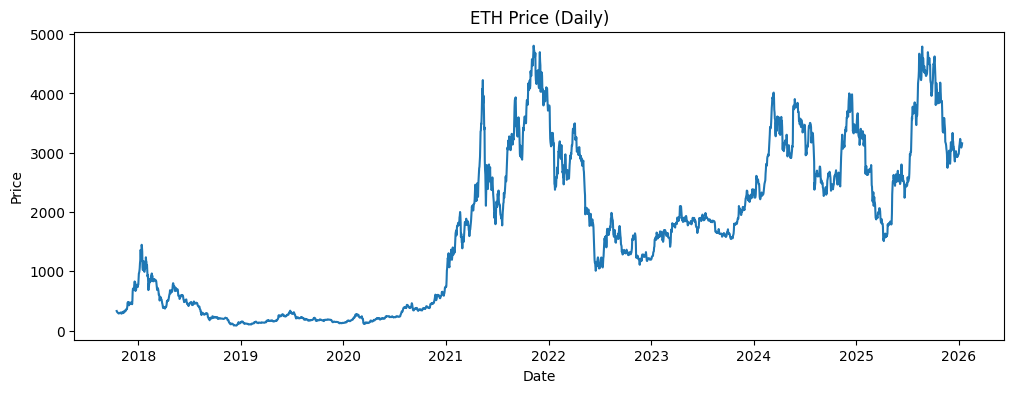

In [146]:

plt.figure(figsize=(12, 4))
plt.plot(df['block_date'], df['eth_price'])
plt.title("ETH Price (Daily)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()


- Feature Distributions

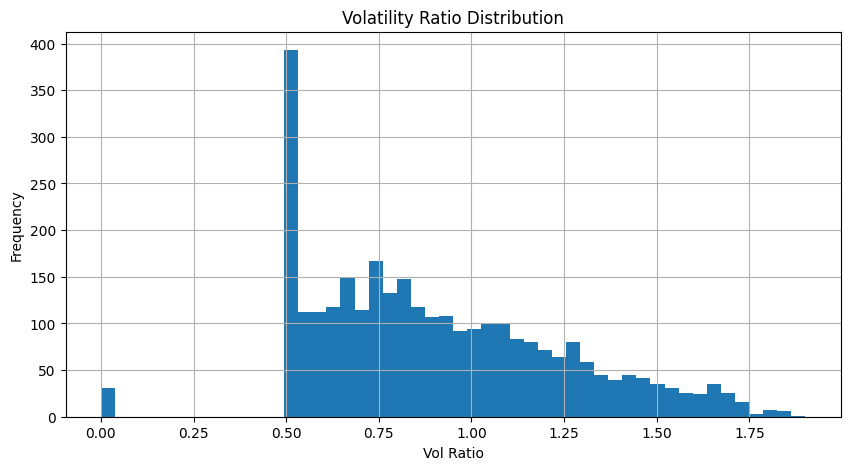

In [147]:

plt.figure(figsize=(10, 5))
df['vol_ratio'].hist(bins=50)
plt.title("Volatility Ratio Distribution")
plt.xlabel("Vol Ratio")
plt.ylabel("Frequency")
plt.show()

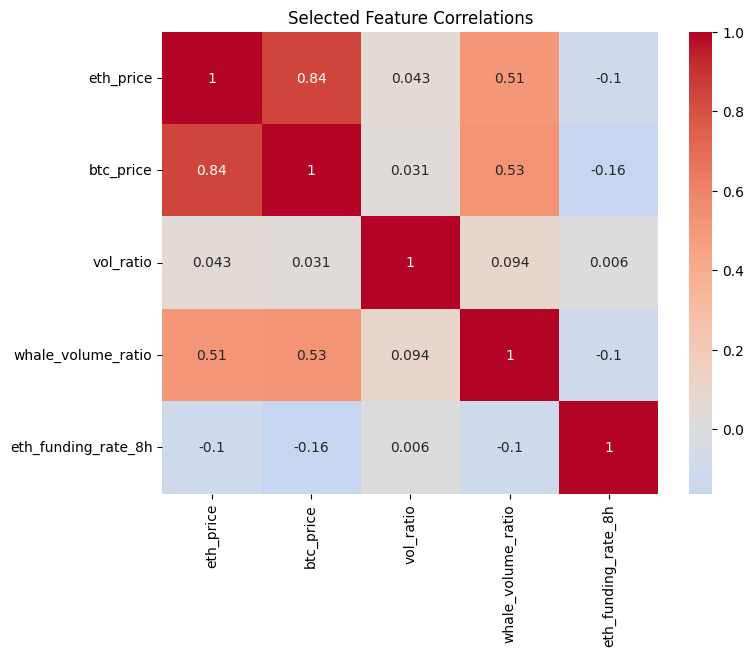

In [148]:
# =========================
# Feature Correlation (Selected)
# =========================

selected_features = [
    "eth_price",
    "btc_price",
    "vol_ratio",
    "whale_volume_ratio",
    "eth_funding_rate_8h"
]

corr_matrix = df[selected_features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0)
plt.title("Selected Feature Correlations")
plt.show()


In [149]:
corr_matrix

,eth_price,btc_price,vol_ratio,whale_volume_ratio,eth_funding_rate_8h
eth_price,1.000000,0.841791,0.043387,0.511914,-0.102093
btc_price,0.841791,1.000000,0.031003,0.525912,-0.161852
vol_ratio,0.043387,0.031003,1.000000,0.094396,0.006026
whale_volume_ratio,0.511914,0.525912,0.094396,1.000000,-0.101727
eth_funding_rate_8h,-0.102093,-0.161852,0.006026,-0.101727,1.000000



Regime Distribution (Proportions):
regime_code
R0    0.329681
R5    0.260956
R2    0.114542
R1    0.112218
R3    0.108566
R4    0.074037
Name: proportion, dtype: float64


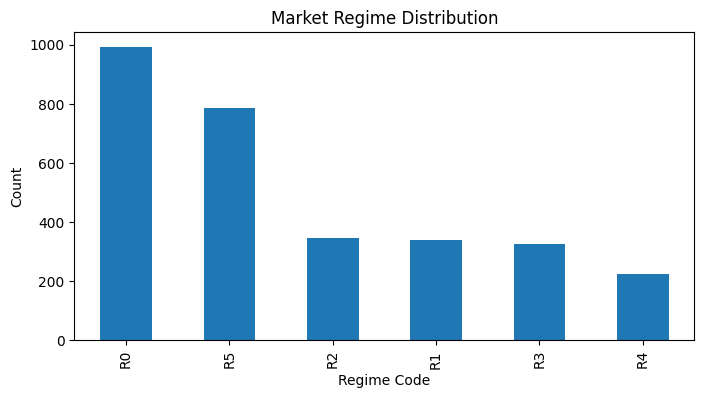


R5 regime occurrences: 786 (26.10%)


In [150]:
# =========================
# Regime Analysis
# =========================

print("\nRegime Distribution (Proportions):")
print(df["regime_code"].value_counts(normalize=True))

plt.figure(figsize=(8, 4))
df["regime_code"].value_counts().plot(kind="bar")
plt.title("Market Regime Distribution")
plt.xlabel("Regime Code")
plt.ylabel("Count")
plt.show()

# R5 specific analysis
r5_count = (df["regime_code"] == "R5").sum()
print(f"\nR5 regime occurrences: {r5_count} ({r5_count/len(df)*100:.2f}%)")

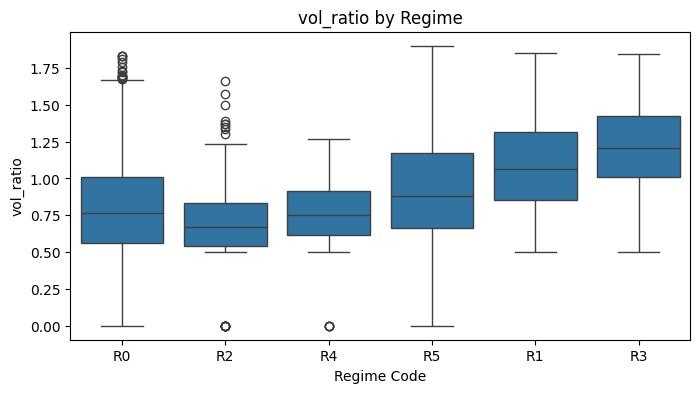

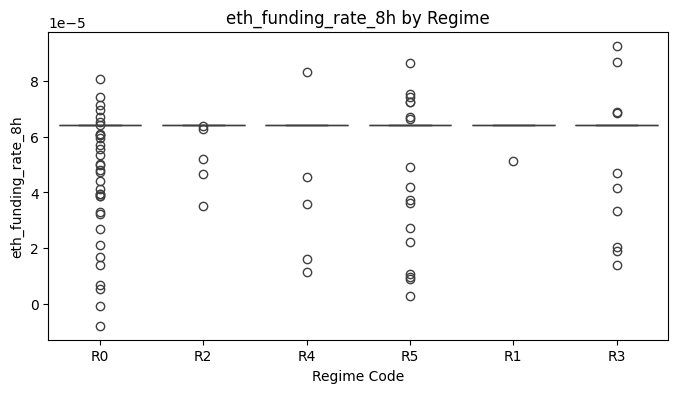

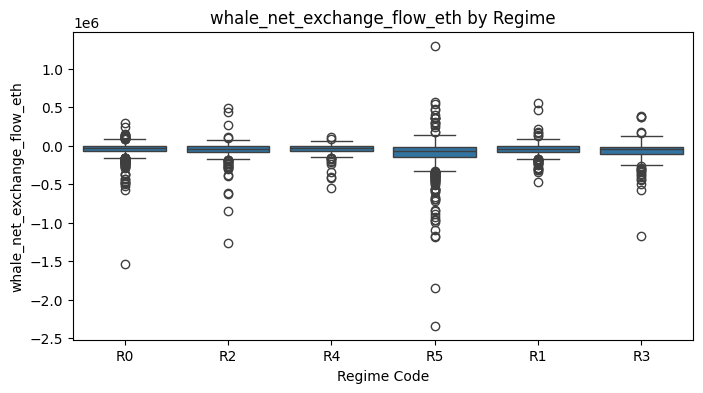

In [151]:

# =========================
# Feature Behavior by Regime
# =========================

core_features = ["vol_ratio", "eth_funding_rate_8h", "whale_net_exchange_flow_eth"]

for feature in core_features:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x="regime_code", y=feature, data=df)
    plt.title(f"{feature} by Regime")
    plt.xlabel("Regime Code")
    plt.ylabel(feature)
    plt.show()

#### Feature Importance Analysis

This section evaluates which features are most informative for predicting directional outcomes,
without asserting causal relationships.

Feature importance is assessed using:
- a linear baseline model (interpretability)
- a tree-based model (non-linear interactions)

All analysis is performed on pre-engineered features produced by the pipeline.


In [152]:
# =========================
# ML Feature Analysis
# =========================

from loader.targets import create_targets_two_tier

df_ml = create_targets_two_tier(df.copy())

# Define column types
TIME_COLS = ["block_date", "date"]
TARGET_COLS = ["target_t2", "return_t2", "y_long_t2", "y_short_t2", "threshold_t2", "rolling_vol_30"]
CATEGORICAL_COLS = ["regime_code", "btc_regime", "vol_regime", "regime"]

# Get numeric features only
FEATURE_COLS = [
    c for c in df_ml.columns
    if c not in TARGET_COLS + TIME_COLS + CATEGORICAL_COLS
    and df_ml[c].dtype in ['int64', 'float64']
]

# Drop rows with NaN
df_ml = df_ml.dropna(subset=FEATURE_COLS + ["target_t2"]).reset_index(drop=True)

print(f"\nFeature columns: {len(FEATURE_COLS)}")
print(f"Rows after dropna: {len(df_ml)}")

🎯 Creating two-tier targets...

📊 Target Distribution (Two-Tier SHORT):
  DOWN :  498 ( 16.5%)
  FLAT : 1921 ( 63.8%)
  UP   :  593 ( 19.7%)

  Tier 1 (crash):      229
  Tier 2 (breakdown):  302
  Total DOWN:          498

Feature columns: 54
Rows after dropna: 3012


In [153]:
# =========================
# Time-Aware Train/Val Split
# =========================

split_date = "2023-01-01"
train_df = df_ml[df_ml["block_date"] < split_date]
val_df = df_ml[df_ml["block_date"] >= split_date]

X_train = train_df[FEATURE_COLS]
y_train = train_df["target_t2"]
X_val = val_df[FEATURE_COLS]
y_val = val_df["target_t2"]

print(f"\nTrain: {len(X_train)} rows, Val: {len(X_val)} rows")


Train: 1903 rows, Val: 1109 rows


In [154]:
# =========================
# Feature-Target Correlation
# =========================

# Calculate correlation matrix including target
corr_with_target = df_ml[FEATURE_COLS + ["target_t2"]].corr()

# Extract correlations with target only
target_corr = corr_with_target["target_t2"].drop("target_t2")
target_corr = target_corr.sort_values(key=abs, ascending=False)

# Display as styled table
target_corr_df = pd.DataFrame({
    'Feature': target_corr.index,
    'Correlation': target_corr.values
})

print("\nTop 20 Features Correlated with Target:")
display(target_corr_df.head(20))


Top 20 Features Correlated with Target:


,Feature,Correlation
0,eth_ret_lag1,0.198420
1,btc_ret_lag1,0.193794
2,btc_rsi,0.138639
3,whale_volume_ratio_delta_3d,-0.123673
4,whale_exchange_deposits_eth,-0.122868
5,vol_ratio,-0.120154
6,eth_rsi,0.116530
7,eth_vol7,-0.116491
8,whale_exchange_withdrawals_eth,-0.100661
9,exchange_volume_ratio,-0.099027


In [155]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

linear_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000))
])

X_train = train_df[FEATURE_COLS]
y_train = train_df["target_t2"]

X_val   = val_df[FEATURE_COLS]
y_val   = val_df["target_t2"]

linear_model.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work

In [156]:
linear_model.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work

In [157]:
coef_df = pd.DataFrame({
    "feature": FEATURE_COLS,
    "coefficient": linear_model.named_steps["clf"].coef_[0]
})

coef_df["abs_coef"] = coef_df["coefficient"].abs()
coef_df = coef_df.sort_values("abs_coef", ascending=False)

coef_df.head(15)


,feature,coefficient,abs_coef
28,whale_exchange_flow_ratio,-0.974905,0.974905
25,net_exchange_flow_ratio,0.881094,0.881094
48,btc_vol30,0.533908,0.533908
53,vol_ratio,0.465614,0.465614
34,whale_volume_ratio_delta_3d,0.400434,0.400434
47,btc_vol7,-0.340990,0.340990
17,btc_price,-0.339438,0.339438
51,eth_btc_ratio_ma7,-0.325769,0.325769
50,eth_btc_ratio,0.317509,0.317509
33,exchange_flow_share,0.303513,0.303513


- **Visualization**

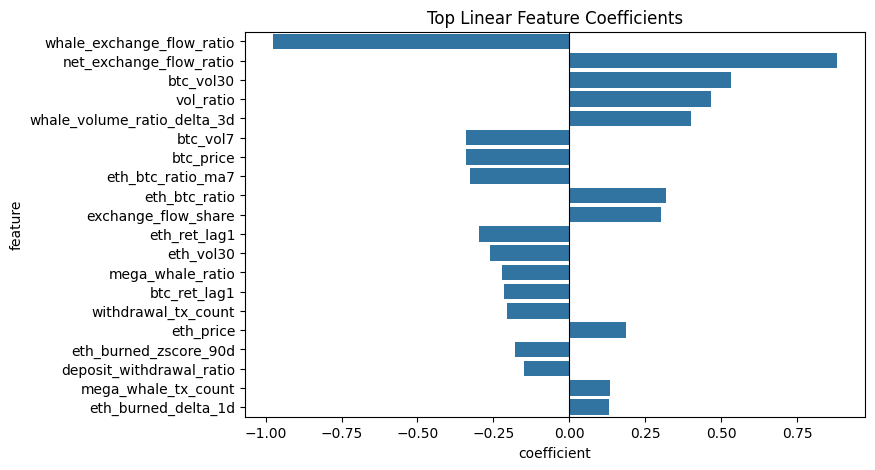

In [158]:
top_n = 20

plt.figure(figsize=(8, 5))
sns.barplot(
    data=coef_df.head(top_n),
    x="coefficient",
    y="feature"
)
plt.title("Top Linear Feature Coefficients")
plt.axvline(0, color="black", linewidth=0.8)
plt.show()


- **Tree-Based Model (Non-Linear Importance)**

In [159]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    min_samples_leaf=20,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",20
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

- **Tree-Based Feature Importance**

In [160]:
rf_importance = pd.DataFrame({
    "feature": FEATURE_COLS,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

rf_importance.head(15)


,feature,importance
36,eth_ret_lag1,0.101240
43,btc_ret_lag1,0.092304
53,vol_ratio,0.075278
34,whale_volume_ratio_delta_3d,0.070022
11,whale_exchange_deposits_eth,0.051825
40,eth_vol7,0.041580
16,whale_net_exchange_flow_eth,0.030746
10,exchange_volume_ratio,0.024535
7,non_exchange_ratio,0.024241
33,exchange_flow_share,0.023251


In [161]:
# Feature Importance Table (Coefficients)
coefs = linear_model.named_steps["clf"].coef_[0]
fi_df = pd.DataFrame({
    "feature": FEATURE_COLS,
    "coefficient": coefs
})
fi_df = fi_df.sort_values("coefficient", key=abs, ascending=False).head(20)

# Display as a simple formatted table

print("Top 20 Features by Linear Model Coefficient")
print(f"{'Feature':<40} {'Coefficient':>15}")

for _, row in fi_df.iterrows():
    feature = row["feature"]
    coeff = row["coefficient"]
    print(f"{feature:<40} {coeff:>15.6f}")



Top 20 Features by Linear Model Coefficient
Feature                                      Coefficient
whale_exchange_flow_ratio                      -0.974905
net_exchange_flow_ratio                         0.881094
btc_vol30                                       0.533908
vol_ratio                                       0.465614
whale_volume_ratio_delta_3d                     0.400434
btc_vol7                                       -0.340990
btc_price                                      -0.339438
eth_btc_ratio_ma7                              -0.325769
eth_btc_ratio                                   0.317509
exchange_flow_share                             0.303513
eth_ret_lag1                                   -0.298713
eth_vol30                                      -0.262673
mega_whale_ratio                               -0.221156
btc_ret_lag1                                   -0.215776
withdrawal_tx_count                            -0.204567
eth_price                                   

In [ ]:
# =========================
# Mutual Information - Table Display
# =========================

from sklearn.feature_selection import mutual_info_classif

mi_scores = mutual_info_classif(X_train, y_train, random_state=42)
mi_df = pd.DataFrame({
    "feature": FEATURE_COLS,
    "mi_score": mi_scores
})
mi_df = mi_df.sort_values("mi_score", ascending=False).head(20)

# Display as a simple formatted table

print("Top 20 Features by Mutual Information")
print(f"{'Feature':<40} {'MI Score':>15}")
print("-" * 60)

for _, row in mi_df.iterrows():
    feature = row["feature"]
    score = row["mi_score"]
    print(f"{feature:<40} {score:>15.6f}")


Top 20 Features by Mutual Information
Feature                                         MI Score
------------------------------------------------------------
eth_vol7                                        0.055501
btc_ret_lag1                                    0.055060
vol_ratio                                       0.054326
exchange_flow_share                             0.052644
eth_vol30                                       0.048765
eth_ret_lag1                                    0.042046
eth_btc_ratio                                   0.036444
eth_btc_corr_30d                                0.035413
non_exchange_ratio                              0.035318
exchange_volume_ratio                           0.034494
eth_btc_ratio_ma7                               0.033914
eth_price                                       0.033249
btc_vol7                                        0.031245
btc_vol30                                       0.029732
whale_volume_eth                              

In [163]:
leakage = [c for c in FEATURE_COLS if "t2" in c or "return" in c]
print("Leakage candidates:", leakage)


Leakage candidates: []


In [164]:
def rolling_linear_importance(df, feature_cols, target, window=365):
    coefs = []

    for i in range(window, len(df)):
        sub = df.iloc[i-window:i]
        X = sub[feature_cols]
        y = sub[target]

        model = Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(max_iter=1000))
        ])

        model.fit(X, y)

        coefs.append(model.named_steps["clf"].coef_[0])

    return pd.DataFrame(coefs, columns=feature_cols)


In [165]:
rolling_coefs = rolling_linear_importance(
    df_ml.sort_values("block_date"),
    FEATURE_COLS,
    "target_t2"
)

stability = rolling_coefs.std().sort_values()
stability.head(10)


eth_funding_rate_8h            0.036444
mega_whale_volume_eth          0.090148
whale_volume_eth               0.092753
whale_tx_count                 0.131439
mega_whale_tx_count            0.131460
eth_burned_delta_1d            0.137954
whale_volume_ratio_delta_1d    0.140331
block_fullness_delta_1d        0.145363
deposit_tx_count               0.149527
mega_whale_ratio               0.155218
dtype: float64

In [166]:
regime_models = {}

for regime in df_ml["regime_code"].unique():
    sub = df_ml[df_ml["regime_code"] == regime]

    if len(sub) < 300:
        continue  # skip thin regimes

    X = sub[FEATURE_COLS]
    y = sub["target_t2"]

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000))
    ])

    model.fit(X, y)
    regime_models[regime] = model


In [167]:
corr = X_train.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

to_drop = [
    col for col in upper.columns
    if any(upper[col] > 0.9)
]

print("Highly correlated features:", to_drop)


Highly correlated features: ['mega_whale_volume_eth', 'whale_volume_eth', 'exchange_volume_ratio', 'whale_tx_count', 'eth_price', 'whale_exchange_flow_ratio', 'eth_btc_ratio_ma7']


- **Feature Pruning:** We drop weak features and repeat features importance.


In [168]:
DROP_FEATURES = [
    "whale_volume_eth",
    "whale_tx_count",
    "whale_exchange_flow_ratio",
    "eth_price"
]

FEATURE_COLS_PRUNED = [
    c for c in FEATURE_COLS if c not in DROP_FEATURES
]


In [171]:
X_train_p = train_df[FEATURE_COLS_PRUNED]
X_val_p   = val_df[FEATURE_COLS_PRUNED]

y_train = train_df["target_t2"]
y_val   = val_df["target_t2"]


In [172]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

linear_model_p = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000))
])

linear_model_p.fit(X_train_p, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work

In [173]:
coef_df_p = pd.DataFrame({
    "feature": FEATURE_COLS_PRUNED,
    "coefficient": linear_model_p.named_steps["clf"].coef_[0]
})

coef_df_p["abs_coef"] = coef_df_p["coefficient"].abs()
coef_df_p = coef_df_p.sort_values("abs_coef", ascending=False)

coef_df_p.head(15)


,feature,coefficient,abs_coef
44,btc_vol30,0.511184,0.511184
49,vol_ratio,0.463533,0.463533
30,whale_volume_ratio_delta_3d,0.405519,0.405519
46,eth_btc_ratio,0.387196,0.387196
43,btc_vol7,-0.340976,0.340976
47,eth_btc_ratio_ma7,-0.321527,0.321527
32,eth_ret_lag1,-0.292559,0.292559
37,eth_vol30,-0.245142,0.245142
39,btc_ret_lag1,-0.222165,0.222165
0,withdrawal_tx_count,-0.211672,0.211672


In [174]:
from sklearn.ensemble import RandomForestClassifier

rf_model_p = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    min_samples_leaf=20,
    random_state=42,
    n_jobs=-1
)

rf_model_p.fit(X_train_p, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",20
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [175]:
rf_importance_p = pd.DataFrame({
    "feature": FEATURE_COLS_PRUNED,
    "importance": rf_model_p.feature_importances_
}).sort_values("importance", ascending=False)

rf_importance_p.head(15)


,feature,importance
39,btc_ret_lag1,0.101625
32,eth_ret_lag1,0.099164
30,whale_volume_ratio_delta_3d,0.083196
49,vol_ratio,0.075933
10,whale_exchange_deposits_eth,0.053319
36,eth_vol7,0.046132
14,whale_net_exchange_flow_eth,0.031056
6,non_exchange_ratio,0.026171
29,exchange_flow_share,0.024193
38,eth_rsi,0.022798


#### **Coefficient Stability Analysis**
- Define Rolling Windows

In [176]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

WINDOW_START = "2018-01-01"
WINDOW_STEP_MONTHS = 6

model_template = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000))
])


- Rolling Coefficient Extraction

In [178]:
from dateutil.relativedelta import relativedelta

coef_history = []

start_date = pd.to_datetime(WINDOW_START)
end_date = df_ml["block_date"].max().tz_localize(None)

current_end = start_date + relativedelta(months=12)

while current_end <= end_date:
    window_df = df_ml[df_ml["block_date"].dt.tz_localize(None) <= current_end]
    
    if len(window_df) < 500:
        current_end += relativedelta(months=WINDOW_STEP_MONTHS)
        continue
    
    X_w = window_df[FEATURE_COLS_PRUNED]
    y_w = window_df["target_t2"]
    
    model = model_template
    model.fit(X_w, y_w)
    
    coefs = model.named_steps["clf"].coef_[0]
    
    coef_history.append(
        pd.DataFrame({
            "feature": FEATURE_COLS_PRUNED,
            "coefficient": coefs,
            "window_end": current_end
        })
    )
    
    current_end += relativedelta(months=WINDOW_STEP_MONTHS)

coef_history_df = pd.concat(coef_history, ignore_index=True)

- Stability Metrics

In [181]:
stability_df = (
    coef_history_df
    .groupby("feature")["coefficient"]
    .agg([
        ("mean_coef", "mean"),
        ("std_coef", "std"),
        ("sign_flips", lambda x: (np.sign(x).diff().fillna(0) != 0).sum()),
        ("obs", "count")
    ])
    .reset_index()
)

stability_df["cv"] = stability_df["std_coef"] / stability_df["mean_coef"].abs()
stability_df = stability_df.sort_values("cv")
stability_df.head(15)


,feature,mean_coef,std_coef,sign_flips,obs,cv
48,whale_volume_ratio_delta_3d,0.370125,0.035069,0,14,0.094749
2,btc_ret_lag1,-0.244080,0.027059,0,14,0.110861
17,eth_ret_lag1,-0.262855,0.030943,0,14,0.117720
40,vol_ratio,0.539433,0.086687,0,14,0.160701
12,eth_btc_ratio,0.369482,0.060792,0,14,0.164534
13,eth_btc_ratio_ma7,-0.316198,0.058491,0,14,0.184983
49,withdrawal_tx_count,-0.192841,0.035889,0,14,0.186105
28,mega_whale_ratio,-0.154197,0.030565,0,14,0.198220
34,non_exchange_tx_count,-0.189486,0.039021,0,14,0.205929
10,deposit_withdrawal_ratio,-0.131335,0.036379,0,14,0.276998


- All 15 features shown are STABLE.
- No sign flips. Low coefficient of variation. Consistent direction across 14 rolling windows.

#### **Model Traing and Selection**(Regime-Aware, Leakage-Safe)
- FINAL FEATURE LOCK

In [182]:
FINAL_FEATURES = [
    "whale_volume_ratio_delta_3d",
    "btc_ret_lag1",
    "eth_ret_lag1",
    "vol_ratio",
    "eth_btc_ratio",
    "eth_btc_ratio_ma7",
    "withdrawal_tx_count",
    "mega_whale_ratio",
    "non_exchange_tx_count",
    "deposit_withdrawal_ratio",
    "btc_vol30",
    "btc_vol7",
    "exchange_volume_ratio",
    "std_whale_tx_size_eth"
]


- Lock dataset

In [183]:
X_train = train_df[FINAL_FEATURES]
y_train = train_df["target_t2"]

X_val = val_df[FINAL_FEATURES]
y_val = val_df["target_t2"]


- **Binary Targets**


In [ ]:

# LONG: UP vs rest
y_train_long = (y_train == 1).astype(int)
y_val_long   = (y_val == 1).astype(int)

# SHORT: DOWN vs rest
y_train_short = (y_train == -1).astype(int)
y_val_short   = (y_val == -1).astype(int)

print("LONG target distribution:")
print(y_train_long.value_counts(normalize=True))

print("\nSHORT target distribution:")
print(y_train_short.value_counts(normalize=True))


: 

- Base-Line: Logistic Regression

In [ ]:
from sklearn.metrics import roc_auc_score

rf_long = RandomForestClassifier(
    n_estimators=400,
    max_depth=6,
    min_samples_leaf=30,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_long.fit(X_train, y_train_long)

rf_long_probs = rf_long.predict_proba(X_val)[:, 1]
rf_long_auc = roc_auc_score(y_val_long, rf_long_probs)

print(f"Random Forest LONG AUC: {rf_long_auc:.4f}")


Logistic AUC: 0.6511


- Random Forest(Long Model)

In [ ]:
from sklearn.metrics import roc_auc_score

rf_long = RandomForestClassifier(
    n_estimators=400,
    max_depth=6,
    min_samples_leaf=30,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_long.fit(X_train, y_train_long)

rf_long_probs = rf_long.predict_proba(X_val)[:, 1]
rf_long_auc = roc_auc_score(y_val_long, rf_long_probs)

print(f"Random Forest LONG AUC: {rf_long_auc:.4f}")


ValueError: multi_class must be in ('ovo', 'ovr')

- Random Forest(Short Model)

In [ ]:
rf_short = RandomForestClassifier(
    n_estimators=400,
    max_depth=6,
    min_samples_leaf=30,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_short.fit(X_train, y_train_short)

rf_short_probs = rf_short.predict_proba(X_val)[:, 1]
rf_short_auc = roc_auc_score(y_val_short, rf_short_probs)

print(f"Random Forest SHORT AUC: {rf_short_auc:.4f}")
